<a href="https://colab.research.google.com/github/kalinkabel/VisaoComputacional/blob/main/Restricted_Boltzmann_Machine_RBM_with_hands.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Goal ⚽️ 🥅 : Generative and unsupervised learning with Restricted Boltzmann Machine (RBM)
===

An RBM are a basic form of [Autoencoder](https://www.cs.toronto.edu/~hinton/science.pdf?).  It can automatically extract <b>meaningful</b> features from a given input.

Train RBM with [Laurence Moroney](https://laurencemoroney.com/datasets.html) Rock Paper Scissors Dataset.

Think of RBM as a model (kind of [Autoencoder](https://www.cs.toronto.edu/~hinton/science.pdf?)) that has been trained based on images of a dataset of many hand movements. Also, imagine that the RBM network has only two hidden nodes, where one node encodes the weight and, and the other encodes the size.

In a sense, the different configurations represent different movement of hand: Rock Paper Scissors.

In a training process, through many forward and backward passes, the RBM adjusts its weights to send a stronger signal to either the Rock node (0, 0, 1) or the Paper node (0, 1, 0) or  Scissors(1, 0, 0) in the hidden layer, given the pixels of images.

Now, given a random hand movements in hidden layer, which distribution of pixels should we expect? RBM can give you 2 things. First, it encodes your images in hidden layer. Second, it gives you the probability of observing a case, given some hidden values.

After training the model is briefly enable to generate photo of hand, ie:

> Here give source with random image and do some noises on it.

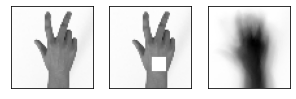

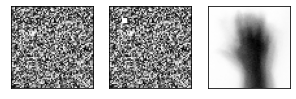

# How does it work?
RBM is a 2 layer neural network. Simply, RBM takes the inputs and translates those into a set of binary values that represents them in the hidden layer. Then, these numbers can be translated back to reconstruct the inputs. Through several forward and backward passes, the RBM will be trained, and a trained RBM can reveal which features are the most important ones when detecting patterns.   

<h4>What are the applications of an RBM?</h4>
RBM is useful for <a href='http://www.cs.utoronto.ca/~hinton/absps/netflixICML.pdf?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDL0120ENSkillsNetwork20629446-2021-01-01'>  Collaborative Filtering</a>, dimensionality reduction, classification, regression, feature learning, topic modeling.

# Unsupervised learning

In an unsupervised task, we try to form a model for $P(x)$, where $P$ is the probability given $x$ as an input vector.

Generative learning is one kind of unsupervised learning algorithms.

## Generative learning

Give an example:

Looking at fruits, we can build a model of what Apple looks like. Then, looking at Kiwi, we can build a separate model of what Kiwi looks like.

**Our goal**: We build a model of what a hand looks like

In [2]:
import os
import sys
from PIL import Image
from PIL import ImageOps
from PIL import ImageDraw
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import *
from IPython.display import clear_output

In [3]:
train_dir = '/content/drive/MyDrive/train/train'
cv_dir = '/content/drive/MyDrive/cv/valid'
test_dir = '/content/drive/MyDrive/test/test'

# Help methods

In [4]:
def scale_to_unit_interval(ndar, eps=1e-8):
    """ Scales all values in the ndarray ndar to be between 0 and 1 """
    ndar = ndar.copy()
    ndar -= ndar.min()
    ndar *= 1.0 / (ndar.max() + eps)
    return ndar


def tile_raster_images(X, img_shape, tile_shape, tile_spacing=(0, 0),
                       scale_rows_to_unit_interval=True,
                       output_pixel_vals=True):
    """
    Transform an array with one flattened image per row, into an array in
    which images are reshaped and layed out like tiles on a floor.

    This function is useful for visualizing datasets whose rows are images,
    and also columns of matrices for transforming those rows
    (such as the first layer of a neural net).

    :type X: a 2-D ndarray or a tuple of 4 channels, elements of which can
    be 2-D ndarrays or None;
    :param X: a 2-D array in which every row is a flattened image.

    :type img_shape: tuple; (height, width)
    :param img_shape: the original shape of each image

    :type tile_shape: tuple; (rows, cols)
    :param tile_shape: the number of images to tile (rows, cols)

    :param output_pixel_vals: if output should be pixel values (i.e. int8
    values) or floats

    :param scale_rows_to_unit_interval: if the values need to be scaled before
    being plotted to [0,1] or not


    :returns: array suitable for viewing as an image.
    (See:`Image.fromarray`.)
    :rtype: a 2-d array with same dtype as X.

    """

    assert len(img_shape) == 2
    assert len(tile_shape) == 2
    assert len(tile_spacing) == 2

    # The expression below can be re-written in a more C style as
    # follows :
    #
    # out_shape    = [0,0]
    # out_shape[0] = (img_shape[0]+tile_spacing[0])*tile_shape[0] -
    #                tile_spacing[0]
    # out_shape[1] = (img_shape[1]+tile_spacing[1])*tile_shape[1] -
    #                tile_spacing[1]
    out_shape = [
        (ishp + tsp) * tshp - tsp
        for ishp, tshp, tsp in zip(img_shape, tile_shape, tile_spacing)
    ]

    if isinstance(X, tuple):
        assert len(X) == 4
        # Create an output numpy ndarray to store the image
        if output_pixel_vals:
            out_array = np.zeros((out_shape[0], out_shape[1], 4),
                                    dtype='uint8')
        else:
            out_array = np.zeros((out_shape[0], out_shape[1], 4),
                                    dtype=X.dtype)

        #colors default to 0, alpha defaults to 1 (opaque)
        if output_pixel_vals:
            channel_defaults = [0, 0, 0, 255]
        else:
            channel_defaults = [0., 0., 0., 1.]

        for i in range(4):
            if X[i] is None:
                # if channel is None, fill it with zeros of the correct
                # dtype
                dt = out_array.dtype
                if output_pixel_vals:
                    dt = 'uint8'
                out_array[:, :, i] = np.zeros(
                    out_shape,
                    dtype=dt
                ) + channel_defaults[i]
            else:
                # use a recurrent call to compute the channel and store it
                # in the output
                out_array[:, :, i] = tile_raster_images(
                    X[i], img_shape, tile_shape, tile_spacing,
                    scale_rows_to_unit_interval, output_pixel_vals)
        return out_array

    else:
        # if we are dealing with only one channel
        H, W = img_shape
        Hs, Ws = tile_spacing

        # generate a matrix to store the output
        dt = X.dtype
        if output_pixel_vals:
            dt = 'uint8'
        out_array = np.zeros(out_shape, dtype=dt)

        for tile_row in range(tile_shape[0]):
            for tile_col in range(tile_shape[1]):
                if tile_row * tile_shape[1] + tile_col < X.shape[0]:
                    this_x = X[tile_row * tile_shape[1] + tile_col]
                    if scale_rows_to_unit_interval:
                        # if we should scale values to be between 0 and 1
                        # do this by calling the `scale_to_unit_interval`
                        # function
                        this_img = scale_to_unit_interval(
                            this_x.reshape(img_shape))
                    else:
                        this_img = this_x.reshape(img_shape)
                    # add the slice to the corresponding position in the
                    # output array
                    c = 1
                    if output_pixel_vals:
                        c = 255
                    out_array[
                        tile_row * (H + Hs): tile_row * (H + Hs) + H,
                        tile_col * (W + Ws): tile_col * (W + Ws) + W
                    ] = this_img * c
        return out_array


In [5]:
def process_in_duration(message,  proc):
  import datetime

  tm_start = datetime.datetime.now()

  result = proc()

  tm_end = datetime.datetime.now()
  delta = tm_end - tm_start

  print(f"\033[92m{message} used {delta}")
  return result

In [6]:
def plot_history(history):
  loss = history["loss"]

  plt.plot(loss)

  if history.get("best_loss") is not None:
    plt.scatter(history["best_history"], history["best_loss"], c='r')

  plt.show()

In [7]:
def plot_image(img1, img2=None, img3=None):
  plt.figure(figsize=(5, 5))

  ax = plt.subplot(131)
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  plt.imshow(img1, cmap='gray')

  if img2 is not None:
    ax = plt.subplot(132)
    plt.imshow(img2, cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

  if img3 is not None:
    ax = plt.subplot(133)
    plt.imshow(img3, cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

  plt.show()


In [8]:
def plot_image_3D_scatter(img1_array, label1, color1, img2_array=None, label2=None, color2=None):

    xx, yy = np.mgrid[0:img1_array.shape[0], 0:img1_array.shape[1]]

    plt.figure(figsize=(5, 5))
    ax = plt.axes(projection='3d')

    ax.scatter3D(xx, yy, img1_array, c=color1, label=label1)
    if img2_array is not None:
        ax.scatter3D(xx, yy, img2_array, c=color2, label=label2)
    ax.legend()

    plt.show()


In [9]:
def plot_image_hist(title, img1, label1, img2, label2):
    time_line = [i for i in range(256)]

    histr = cv2.calcHist([np.array(img1)], [0], None, [256], [0, 256])
    plt.plot(time_line, histr, color="blue", label=label1)

    histr = cv2.calcHist([np.array(img2)], [0], None, [256], [0, 256])
    plt.plot(time_line, histr, color="red", label=label2)
    plt.xlim([0, 256])

    plt.legend()
    plt.title(title)
    plt.show()

In [10]:
def noisy_image(origin_img,
                left=10,
                upper=10,
                right=13,
                lower=13):

  shape = [left, upper, right, lower]

  noisied_image = origin_img.copy()
  image_fn = ImageDraw.Draw(im=noisied_image)

  image_fn.rectangle(xy=shape, fill="white")
  return noisied_image


In [11]:
def generate_random_image(low, high, size):
  random_mn = np.random.randint(low=low, high=high, size=size)
  random_mn = np.float32(random_mn)
  random_img = Image.fromarray(random_mn)
  random_noisied_img = noisy_image(random_img)
  return random_img, random_noisied_img

In [12]:
def load_images(path, resize=(64, 64)):
    X = []
    labels = ['scissors', 'paper', 'rock']

    for label in labels:
        path_label_dir = os.path.join(path, label)
        if not os.path.exists(path_label_dir):
            print(f"Aviso: pasta '{path_label_dir}' não encontrada. Pulando...")
            continue
        for image_path in os.listdir(path_label_dir):
            img_path = os.path.join(path_label_dir, image_path)
            image_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if image_array is None:
                continue
            image_array = cv2.resize(image_array, resize)
            image_array = (image_array / 255.0).astype(np.float32)
            X.append(image_array)

    return X

In [13]:
x_train = load_images(train_dir, resize=(64, 64)) + load_images(cv_dir, resize=(64, 64))
x_train = np.array(x_train)


image_shape (64, 64)
dim_visible 4096


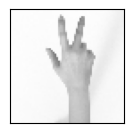

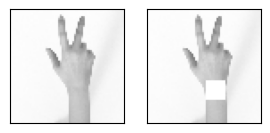

In [14]:
image_shape = (next(iter(x_train))).shape
dim_visible = image_shape[0] * image_shape[1]
print("image_shape", image_shape)
print("dim_visible", dim_visible)

test_image = Image.fromarray((next(iter(x_train*255.0))))
plot_image(test_image)

noisied_image = noisy_image(Image.fromarray(next(iter(x_train*255.0))),
                            left=33,
                            upper=40,
                            right=43,
                            lower=50)

plot_image(test_image, noisied_image)


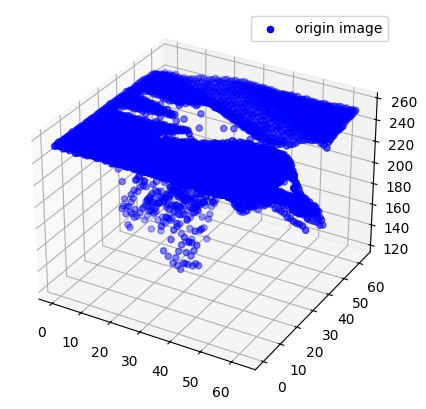

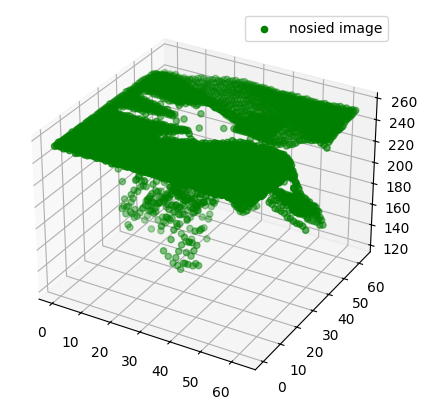

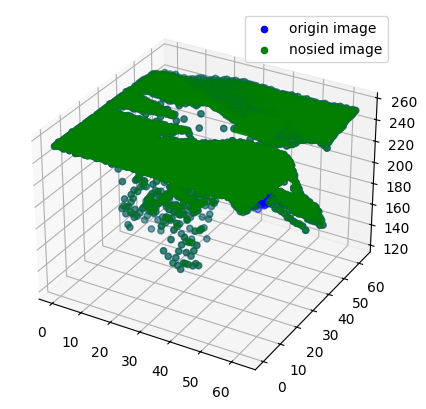

In [15]:
plot_image_3D_scatter(np.array(test_image), "origin image", "blue")
plot_image_3D_scatter(np.array(noisied_image), "nosied image", "green")
plot_image_3D_scatter(np.array(test_image),
                      "origin image",
                       "blue",
                      np.array(noisied_image),
                      "nosied image",
                      "green")


# Data processing

## Flatten all images

Convert images from high-dimensional to 1-D.

In [16]:
x_train = x_train.reshape(x_train.shape[0], -1)
x_train.shape

(2892, 4096)

In [17]:
m = x_train.shape[0] # Sample count
assert dim_visible == x_train.shape[1] # The dimension of input layout

# Train RBM

In [18]:
def gen_predict(img1, img2, proc):
    rebuilt_image = proc()
    plot_image(img1,
               img2,
               rebuilt_image)
    plot_image_3D_scatter(np.array(img1),
                          "origin image",
                          "blue",
                          np.array(rebuilt_image),
                          "rebuilt image",
                          "red")
    plot_image_hist("Color(grayscaled) intensity", img1,
                    "origin", rebuilt_image, "rebuilt")

## Architecture

For training RBM we rely on 2 steps:

<ol>
    <li>Gibbs Sampling</li>
    <li>Contrastive Divergence</li>
</ol>   

We cannot be easily train the model with typical <b>gradient descent (ie. SGD)</b>, this is because that the step of updating of weights and bias comes up with the stochastic, random probabilities of visible and hidden layers.

> I crop some important sections from origin paper regarding of those topic, hopefully it gives good hint and cheat sheet.

## Gibbs Sampling

<h4>Step 1</h4>
Given an input vector $\mathbf{v}$, we are using $p(\mathbf{h}|\mathbf{v})$ to predict the hidden values $\mathbf{h}$.
  $$p({h_j}|\mathbf v)= \sigma\left(\sum_{i=1}^V W_{ij} v_i + h_{bias} \right)$$
The samples are generated from this distribution by generating the uniform random variate vector $\mathbf{\xi} \sim U[0,1]$ of length $H$ and comparing to the computed probabilities as

<center>If $\xi_j>p(h_{j}|\mathbf{v})$, then $h_j=1$, else $h_j=0$.</center>

<h4>Gibbs Sampling Step 2</h4>
Then, knowing the hidden values, we use $p(\mathbf v| \mathbf h)$ for reconstructing of new input values v.

$$p({v_i}|\mathbf h)= \sigma\left(\sum\_{j=1}^H W^{T}*{ij} h_j + v*{bias} \right)$$

The samples are generated from this distribution by generating a uniform random variate vector $\mathbf{\xi} \sim U\[0,1]$ of length $V$ and comparing to the computed probabilities as

<center>If $\xi_i>p(v_{i}|\mathbf{h})$, then $v_i=1$, else $v_i=0$.</center>

Let vectors $\mathbf v_k$ and $\mathbf h_k$ be for the $k$th iteration.  In general, the $kth$ state is generrated as:

<b>Iteration</b> $k$:

$$\mathbf v\_{k-1} \Rightarrow p(\mathbf h\_{k-1}|\mathbf v\_{k-1})\Rightarrow \mathbf h\_{k-1}\Rightarrow p(\mathbf v\_{k}|\mathbf h\_{k-1})\Rightarrow \mathbf v_k$$

## Objective: Contrastive Divergence (CD-K)

The update of the weight matrix is done during the Contrastive Divergence step.

Vectors v0 and vk are used to calculate the activation probabilities for hidden values h0 and hk. The difference between the outer products of those probabilities with input vectors v0 and vk results in the update matrix:

$$\Delta \mathbf W_k =\mathbf v_k \otimes \mathbf h_k - \mathbf v\_{k-1} \otimes \mathbf h\_{k-1}$$

Contrastive Divergence is actually matrix of values that is computed and used to adjust values of the $\mathbf W$ matrix. Changing $\mathbf W$ incrementally leads to training of the  $\mathbf W$ values. Then, on each step (epoch), $\mathbf W$ is updated using the following:

$$\mathbf W_k = \mathbf W\_{k-1} + \alpha \* \Delta \mathbf W_k$$

## Reconstruction steps (rebuiding)

<ul>
    <li> Get one data point from data set, like <i>x</i>, and pass it through the following steps:</li>

<b>Iteration</b> $k=1$:

Sampling (starting with input image)
$$\mathbf x = \mathbf v\_0 \Rightarrow p(\mathbf h\_0|\mathbf v\_0)\Rightarrow \mathbf h\_0 \Rightarrow p(\mathbf v\_1|\mathbf h\_0)\Rightarrow \mathbf v\_1$$\
followed by the CD-k step
$$\Delta \mathbf W\_1 =\mathbf v\_1 \otimes \mathbf h\_1 - \mathbf v\_{0} \otimes \mathbf h\_{0}$$\
$$\mathbf W\_1 = \mathbf W\_{0} + \alpha \* \Delta \mathbf W\_1$$

<li> $\mathbf v_1$ is the reconstruction of $\mathbf x$ sent to the next iteration).</li>

<b>Iteration</b> $k=2$:

Sampling (starting with $\mathbf v\_1$)

$$\mathbf v\_1 \Rightarrow p(\mathbf h\_1|\mathbf v\_1)\Rightarrow \mathbf h\_1\Rightarrow p(\mathbf v\_2|\mathbf h\_1)\Rightarrow \mathbf v\_2$$

followed by the CD-k step
$$\Delta \mathbf W\_2 =\mathbf v\_2 \otimes \mathbf h\_2 - \mathbf v\_{1} \otimes \mathbf h\_{1}$$\
$$\mathbf W\_2 = \mathbf W\_{1} + \alpha \* \Delta \mathbf W\_2$$

<li> $\mathbf v_2$ is the reconstruction of $\mathbf v_1$ sent to the next iteration).</li>    

<b>Iteration</b> $k=K$:

Sampling (starting with $\mathbf v\_{K-1}$)

$$\mathbf v\_{K-1} \Rightarrow p(\mathbf h\_{K-1}|\mathbf v\_{K-1})\Rightarrow \mathbf h\_{K-1}\Rightarrow p(\mathbf v_K|\mathbf h\_{K-1})\Rightarrow \mathbf v_K$$

followed by the CD-k step
$$\Delta \mathbf W_K =\mathbf v_K \otimes \mathbf h_K - \mathbf v\_{K-1} \otimes \mathbf h\_{K-1}$$\
$$\mathbf W_K = \mathbf W\_{K-1} + \alpha \* \Delta \mathbf W_K$$

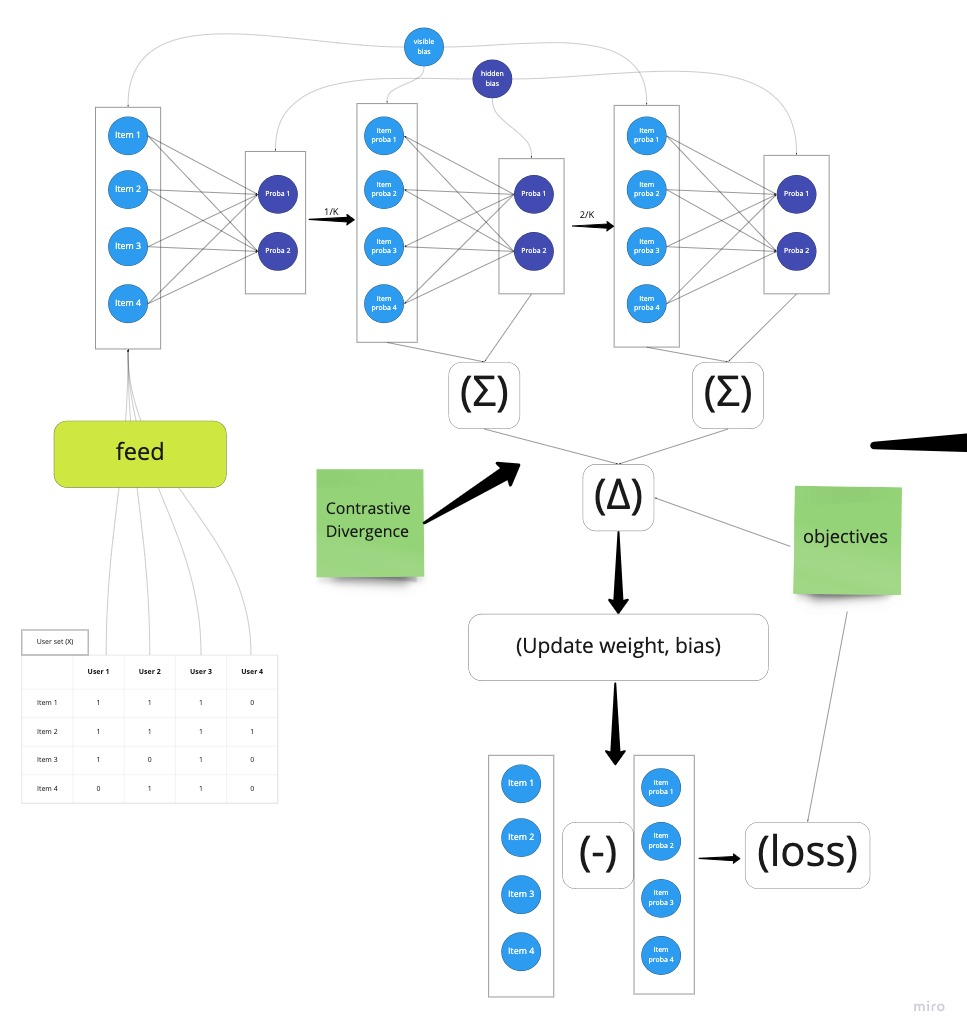

## Cost or loss

Although the loss or cost is not the objective of updating parameter, it turns out that a minimum loss for a stochastic training sample can end the CD-K for that training sample early, which can be useful for low-configuration training machines to "finish the job first".

For a full training job, it is not recommended to switch to a training sample early because of a minimum loss. The reason is that this will prevent the net from continuing to learn more samples.

Check `early_stopping_patience` in `class RBM` .


In [19]:
BATCH_SZ = 200
train_ds = tf.data.Dataset.from_tensor_slices(x_train).shuffle(1024).batch(BATCH_SZ)

class RBM:
  def __init__(self, dim_visible, dim_hidden, early_stopping_patience):
    """_summary_

    Args:
        dim_visible (int): Visible layer dimension, input feature
        dim_hidden (int): Hidden layer dimension, independent events that are inferred from feature units.
        early_stopping_patience (int): When set, if the current loss cannot beat the [best_loss] [early_stopping_patience] times,
                                       the CD-K won't continue train on the current stochastic training sample.
    """
    self.history = {}
    self.history["loss"] = []
    self.history["best_loss"] = None

    self.early_stopping_patience = early_stopping_patience
    self.best_loss_count = 0

    # Interceptors (bias)
    self.bias_visible = tf.Variable(tf.zeros([dim_visible]), tf.float32)
    self.bias_hidden = tf.Variable(tf.zeros([dim_hidden]),  tf.float32)

    # Coofficients (weights)
    ## We define the parameters in the network, the first dimention is connection counts, the 2nd is hidden nodes count.
    self.theta = tf.Variable(tf.zeros([dim_visible, dim_hidden]), tf.float32)

  def forwards(self, visible_state, theta, bias_hidden, train=True):
    z = tf.matmul([visible_state], theta) + bias_hidden

    proba_hidden = tf.nn.sigmoid(z)

    hidden_state = tf.nn.relu(
        tf.sign(proba_hidden - tf.random.uniform(tf.shape(proba_hidden))))

    return hidden_state if train == True else proba_hidden

  def backwards(self, hidden_state, theta, bias_visible, train=True):
    z = tf.matmul(hidden_state, tf.transpose(theta)) + bias_visible

    proba_visible = tf.nn.sigmoid(z)

    visible_state = tf.nn.relu(
        tf.sign(proba_visible - tf.random.uniform(tf.shape(proba_visible))))

    return visible_state[0] if train == True else proba_visible

  def loss_object(self, x0, x1):
    return tf.reduce_mean(tf.square(x0 - x1))

  def fit(self, epochs, K, train_ds, learning_rate):
    for epoch in range(epochs):
      for batch_num, Xs in enumerate(train_ds):
        for idx, x0 in enumerate(Xs):
          for k in range(K):
            x1, delta_W, delta_V, delta_H = self.train_step(x0)
            self.update(delta_W, delta_V, delta_H, learning_rate)

            still_train = self.measure(
                epoch, batch_num, k, K, x0, x1, idx == len(Xs)-1)

            if still_train == False:
              break

  def train_step(self, x):
    ##Gibbs sampling
    # Forward
    visible_state = x
    hidden_state = self.forwards(visible_state, self.theta, self.bias_hidden)
    visible_state_T = tf.transpose([visible_state])

    ## Backward
    rebuilt_visible_state = self.backwards(
        hidden_state, self.theta, self.bias_visible)
    rebuilt_hidden_state = self.forwards(
        rebuilt_visible_state, self.theta, self.bias_hidden)
    rebuilt_visible_state_T = tf.transpose([rebuilt_visible_state])

    # contrastive divergence，CD
    delta_W = tf.matmul(visible_state_T, hidden_state) - \
        tf.matmul(rebuilt_visible_state_T, rebuilt_hidden_state)
    delta_V = visible_state - rebuilt_visible_state
    delta_H = hidden_state - rebuilt_hidden_state

    return rebuilt_visible_state, delta_W, delta_V, delta_H

  def update(self, delta_W, delta_V, delta_H, learning_rate):
    self.theta = self.theta + learning_rate * delta_W
    self.bias_visible = self.bias_visible + \
        learning_rate * tf.reduce_mean(delta_V, 0)
    self.bias_hidden = self.bias_hidden + \
        learning_rate * tf.reduce_mean(delta_H, 0)

  def measure(self, epoch, batch_num, k, K, x0, x1, print):
    def clean():
      sys.stdout.flush()
      clear_output(wait=True)

    loss = self.loss_object(x0, x1)
    self.history["loss"].append(loss)

    if self.early_stopping_patience != None:
      # Remember the best loss and its parameters
      if self.history.get("best_loss") is None or loss < self.history["best_loss"]:
        self.history["best_history"] = len(self.history["loss"])-1
        self.history["best_loss"] = loss

        self.history["best_theta"] = tf.Variable(self.theta, tf.float32)
        self.history["best_bias_visible"] = tf.Variable(
            self.bias_visible, tf.float32)
        self.history["best_bias_hidden"] = tf.Variable(
            self.bias_hidden, tf.float32)

        self.best_loss_count = 1
      else:
        if self.best_loss_count >= self.early_stopping_patience:
          sys.stdout.write(
              f"loss: {loss:.3f}, best_loss: {self.history['best_loss']}, best_loss_count: {self.best_loss_count}, early_stopping_patience: {self.early_stopping_patience}\n")
          self.best_loss_count = 1
          clean()
          return False
        else:
          self.best_loss_count = self.best_loss_count + 1

    if print == True:
      sys.stdout.write(
          f"epoch: {epoch}, batch_num: {batch_num}, k: {k}/{K}, loss: {loss:.3f}, best_loss: {'--' if self.history.get('best_loss') is None else self.history['best_loss']}\n")

    clean()
    return True

  def rebuild(self, image, image_shape):
    image = np.array(image.convert('I').resize(
        image_shape)).ravel().reshape((1, -1))/255.0
    image = tf.cast(image, dtype=tf.float32)

    theta, bias_hidden, bias_visible = (self.theta, self.bias_hidden, self.bias_visible) if self.early_stopping_patience is None else (
        self.history["best_theta"], self.history["best_bias_hidden"], self.history["best_bias_visible"])

    hidden_state = self.forwards(image, theta, bias_hidden, train=False)
    hidden_state = tf.round(hidden_state)
    rebuilt_visible_state = self.backwards(
        hidden_state, theta, bias_visible, train=False)

    rebuilt_visible_state = Image.fromarray(tile_raster_images(
        X=rebuilt_visible_state.numpy(),
        img_shape=image_shape,
        tile_shape=(1, 1),
        tile_spacing=(1, 1)))

    return rebuilt_visible_state


dim_hidden = int(dim_visible*5.0/6.0)
print("dim_hidden", dim_hidden)
print("dim_visible", dim_visible)

restricted_boltzmann = RBM(dim_visible=dim_visible, dim_hidden=dim_hidden, early_stopping_patience=None)


dim_hidden 3413
dim_visible 4096


## 🏃‍♂️ Execute training

In [20]:
process_in_duration("Training done.", lambda: restricted_boltzmann.fit(epochs=50, K=2, train_ds=train_ds, learning_rate=1e-8))

Training done. used 0:39:04.342048


## 📉 Post-training

- Plot loss
- Do one prediction to generate objective

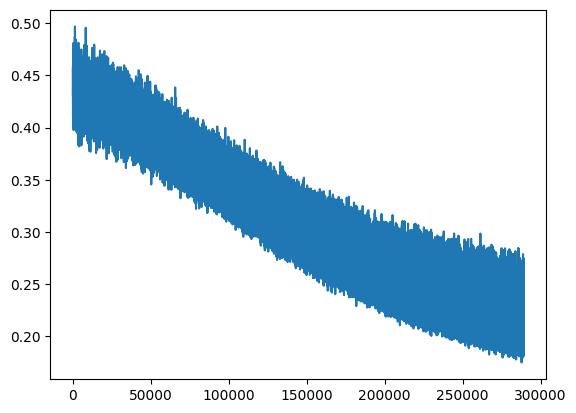

In [21]:
plot_history(restricted_boltzmann.history)

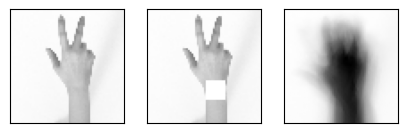

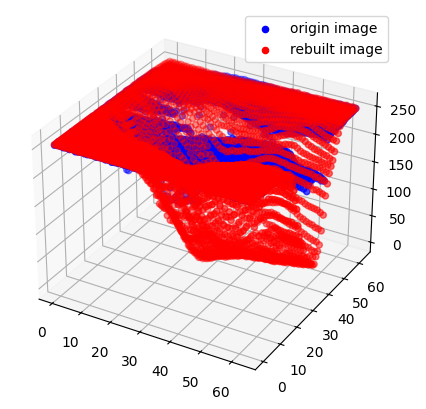

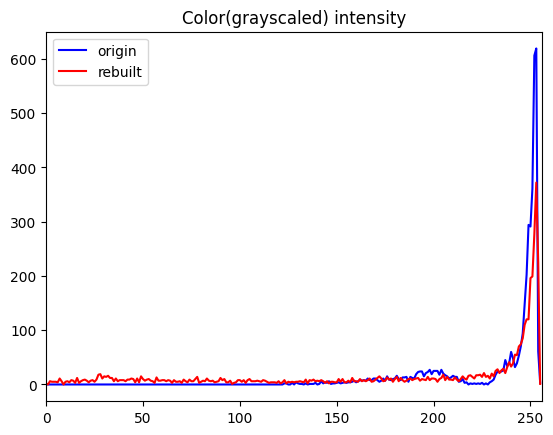

In [22]:
gen_predict(test_image, noisied_image, lambda: restricted_boltzmann.rebuild(noisied_image, image_shape))

## 🏁 Generate image from random noised image source

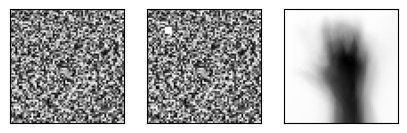

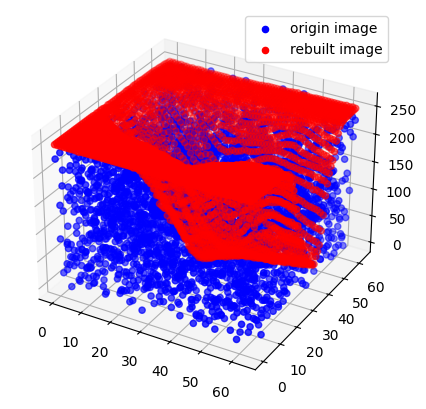

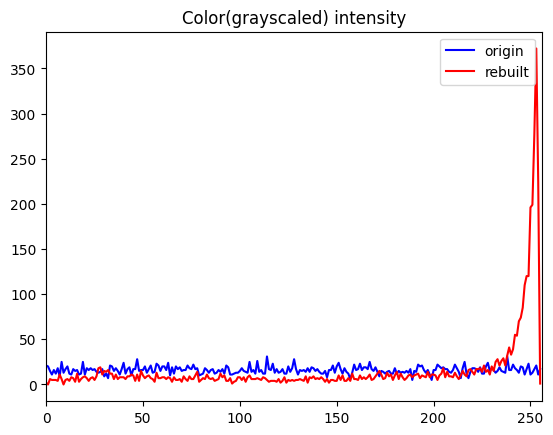

In [23]:
random_img, random_noisied_img = generate_random_image(low=0, high=256, size=(image_shape[0],image_shape[1]))
gen_predict(random_img, random_noisied_img, lambda: restricted_boltzmann.rebuild(random_noisied_img, image_shape))

 😜 Bouns: use classical [Autoencoder](https://www.cs.toronto.edu/~hinton/science.pdf?)
=====
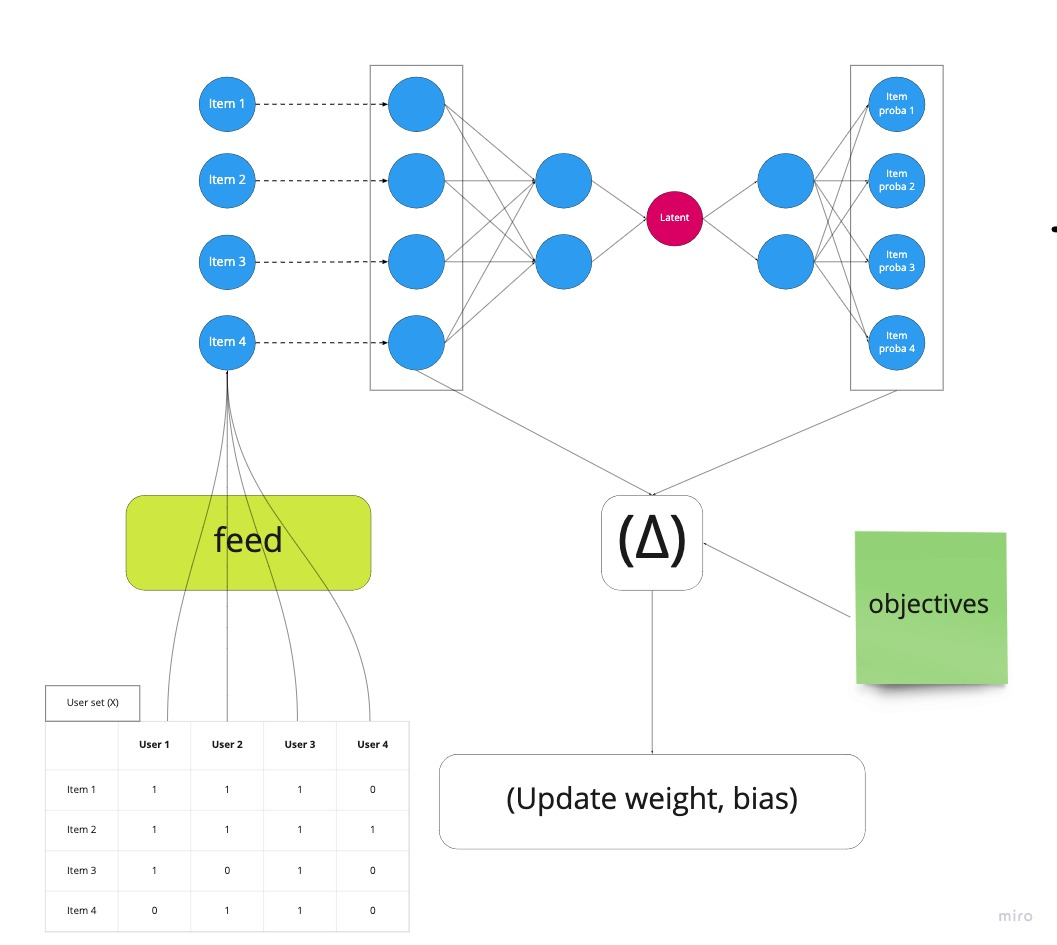

We can use classical [Autoencoder](https://www.cs.toronto.edu/~hinton/science.pdf?) to build a model for the same purpose, it is not part of this notebook, later there will be a medium post to talk about it.

Here just leave the architecture.

In [31]:
BATCH_SZ = 200
train_ds = tf.data.Dataset.from_tensor_slices((x_train, x_train)).shuffle(1024).batch(BATCH_SZ)

class Autoencoder:
  def __init__(self, input_shape, hidden_layers, latent_units):
      self.history = None

      input = tf.keras.Input(shape=input_shape)
      x = input

      # Encoding
      for hidden_layer in hidden_layers:
        x = tf.keras.layers.Dense(
            hidden_layer, activation=tf.keras.activations.relu)(x)

      # Latent
      x = tf.keras.layers.Dense(latent_units)(x)

      # Decoding
      for i, hidden_layer in enumerate(reversed(hidden_layers)):
        activation = tf.keras.activations.relu if i != len(
            hidden_layers) - 1 else tf.keras.activations.sigmoid
        x = tf.keras.layers.Dense(
            hidden_layer, activation=activation)(x)

      self.model = tf.keras.Model(inputs=[input], outputs=[x])
      self.model.summary()

  def fit(self, epochs, train_ds, learning_rate):
    optimizer = tf.keras.optimizers.SGD(
        learning_rate=learning_rate, momentum=.9)
    loss = tf.keras.losses.BinaryCrossentropy()
    self.model.compile(loss=loss, optimizer=optimizer)
    self.history = self.model.fit(
        train_ds, epochs=epochs, verbose=1)
    self.history = self.history.history

  def rebuild(self, image, image_shape):
    # Convert PIL Image to numpy array after resizing
    image_array = np.array(image.resize(image_shape)).ravel().reshape((1, -1))/255.0
    image = tf.cast(image_array, dtype=tf.float32)

    preds = self.model.predict([image])

    image = Image.fromarray(tile_raster_images(
        X=np.asarray(preds),
        img_shape=image_shape,
        tile_shape=(1, 1),
        tile_spacing=(1, 1)))

    return image


hidden_layers = [int(dim_visible/i) for i in range(2, 120)]
hidden_layers = [dim_visible] + hidden_layers
print("hidden_layers", hidden_layers)
autoencoder = Autoencoder((dim_visible,), hidden_layers, 20)

hidden_layers [4096, 2048, 1365, 1024, 819, 682, 585, 512, 455, 409, 372, 341, 315, 292, 273, 256, 240, 227, 215, 204, 195, 186, 178, 170, 163, 157, 151, 146, 141, 136, 132, 128, 124, 120, 117, 113, 110, 107, 105, 102, 99, 97, 95, 93, 91, 89, 87, 85, 83, 81, 80, 78, 77, 75, 74, 73, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60, 59, 58, 57, 56, 56, 55, 54, 53, 53, 52, 51, 51, 50, 49, 49, 48, 48, 47, 47, 46, 46, 45, 45, 44, 44, 43, 43, 42, 42, 41, 41, 40, 40, 40, 39, 39, 39, 38, 38, 37, 37, 37, 36, 36, 36, 35, 35, 35, 35, 34, 34]


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_239 (Dense)               │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_240 (Dense)               │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_241 (Dense)               │ (None, 1365)           │     2,796,885 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_242 (Dense)               │ (None, 1024)           │     1,398,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_243 (Dense)               │ (None, 819)            │       839,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_244 (Dense)               │ (None, 682)            │       559,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_245 (Dense)               │ (None, 585)            │       399,555 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_246 (Dense)               │ (None, 512)            │       300,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_247 (Dense)               │ (None, 455)            │       233,415 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_248 (Dense)               │ (None, 409)            │       186,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_249 (Dense)               │ (None, 372)            │       152,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_250 (Dense)               │ (None, 341)            │       127,193 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_251 (Dense)               │ (None, 315)            │       107,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_252 (Dense)               │ (None, 292)            │        92,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_253 (Dense)               │ (None, 273)            │        79,989 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_254 (Dense)               │ (None, 256)            │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_255 (Dense)               │ (None, 240)            │        61,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 227)            │        54,707 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_257 (Dense)               │ (None, 215)            │        49,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_258 (Dense)               │ (None, 204)            │        44,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_259 (Dense)               │ (None, 195)            │        39,975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_260 (Dense)               │ (None, 186)            │        36,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_261 (Dense)               │ (None, 178)            │        33,286 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_262 (Dense)               │ (None, 170)            │        30,43

 Total params: 50,072,822 (191.01 MB)

 Trainable params: 50,072,822 (191.01 MB)

 Non-trainable params: 0 (0.00 B)

## 🏃‍♂️ Execute training

In [33]:
process_in_duration("Training done.", lambda: autoencoder.fit(epochs=200, train_ds=train_ds, learning_rate=1e-1))

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - loss: 0.6931
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.6926
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6919
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6911
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6903
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6894
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6884
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.6873
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.6860
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.6844
Epoch 11/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6823
Epoch 12/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6793
Epoch 13/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6745
Epoch 14/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6651
Epoch 15/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - los

## 📉 Post-training

- Plot loss
- Do one prediction to generate objective

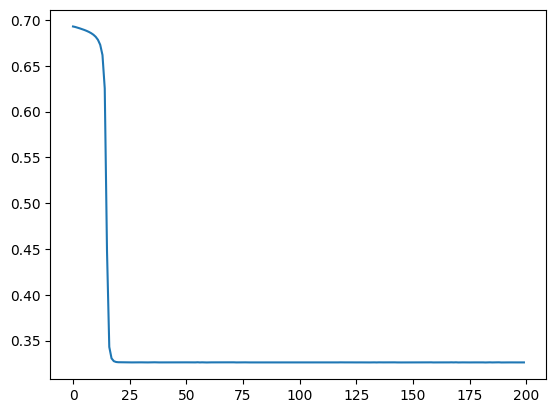

In [34]:
plot_history(autoencoder.history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


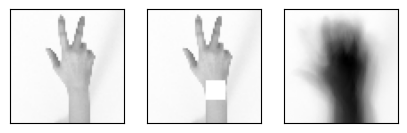

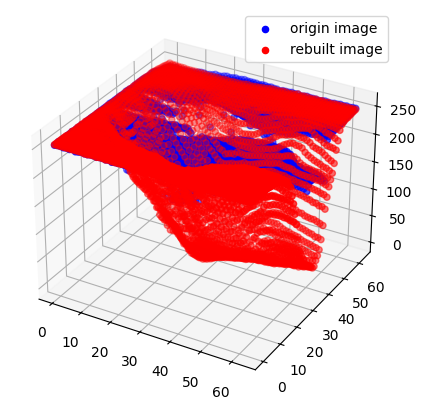

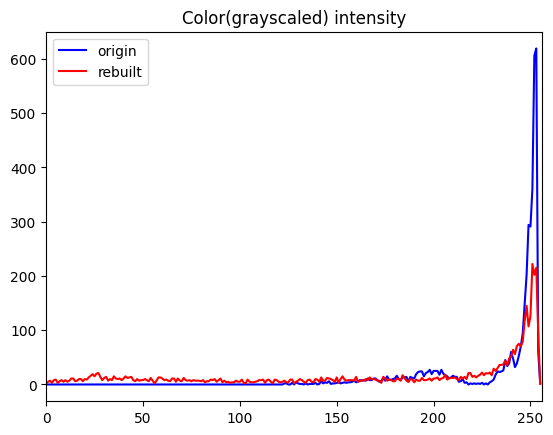

In [35]:
gen_predict(test_image, noisied_image, lambda: autoencoder.rebuild(noisied_image, image_shape))

## 🏁 Generate image from random noised image source

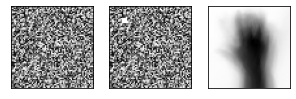

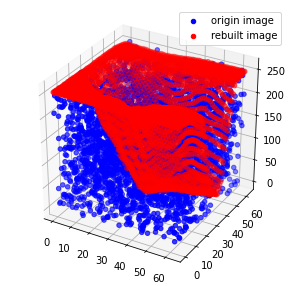

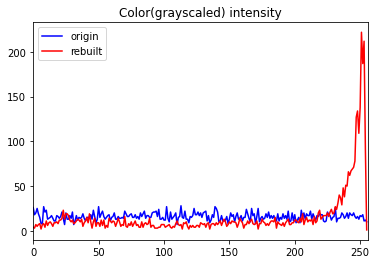

In [ ]:
random_img, random_noisied_img = generate_random_image(low=0, high=256, size=(image_shape[0],image_shape[1]))
gen_predict(random_img, random_noisied_img, lambda: autoencoder.rebuild(random_noisied_img, image_shape))